In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]

📌 Verificação Real do Portfólio (Devem aparecer os 3 produtos no Rating 1):
       Faixa_Rating  Quantidade_Produtos  Percentual (%)
0        ★ Rating 1                    3        0.223714
1       ★★ Rating 2                   43        3.206562
2      ★★★ Rating 3                  777       57.941834
3  ★★★★+ Rating 4/5                  518       38.627890


/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84530/315365225.py:83: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


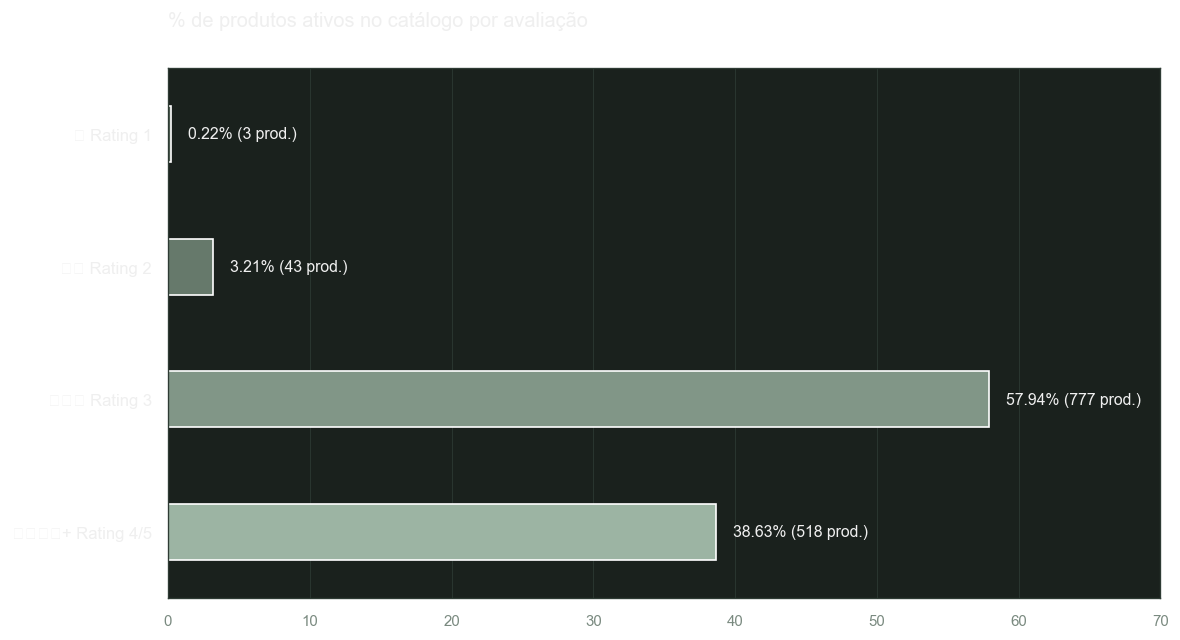

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tratamento e Agrupamento dos Dados
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
df_rating = limpos_df[(limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5)].copy()

bins = [1.0, 2.0, 3.0, 4.0, 5.01]  
labels = ['★ Rating 1', '★★ Rating 2', '★★★ Rating 3', '★★★★+ Rating 4/5']
df_rating['Faixa_Rating'] = pd.cut(df_rating['rating_num'], bins=bins, labels=labels, right=False)

# Contar o número de produtos existentes
df_qtd_rating = df_rating.groupby('Faixa_Rating', observed=False).size().reset_index(name='Quantidade_Produtos')
total_produtos = df_qtd_rating['Quantidade_Produtos'].sum()

# Proporção baseada no portfólio de produtos
df_qtd_rating['Percentual (%)'] = (df_qtd_rating['Quantidade_Produtos'] / total_produtos) * 100

print("📌 Verificação Real do Portfólio (Devem aparecer os 3 produtos no Rating 1):")
print(df_qtd_rating)

# 2. Configuração Visual Unificada (Estilo Verde Institucional)
plt.figure(figsize=(10, 5.5), dpi=120)
cor_fundo_slide = '#1A211D' 
plt.rcParams['figure.facecolor'] = cor_fundo_slide

ax = plt.subplot(111)
ax.set_facecolor(cor_fundo_slide)

# --- MUDANÇA DA PALETA: Tons de verde idênticos ao gráfico de preço médio ---
paleta_branding_verde = ['#4B5F4F', '#637C69', '#7D9A85', '#98B8A2']

ax = sns.barplot(
    data=df_qtd_rating,
    x='Percentual (%)',
    y='Faixa_Rating',
    hue='Faixa_Rating',
    palette=paleta_branding_verde, # <--- Injeção da paleta verde
    legend=False,
    width=0.42,
    ax=ax
)

# --- SISTEMA DE GRADES PADRONIZADO (7 Divisões para match perfeito) ---
ax.set_axisbelow(True)
plt.grid(axis='x', linestyle='-', linewidth=0.6, color='#2E3B34', alpha=0.8)

for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#2E3B34')
    ax.spines[spine].set_linewidth(0.8)

# Mantém a escala de 0 a 70% dividida de 10 em 10
plt.xlim(0, 70)
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70], fontsize=9, color='#7A8A80')
# --------------------------------------------------------

# Mostrar a porcentagem e a quantidade absoluta entre parênteses
for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        idx = int(p.get_y() + p.get_height()/2)
        qtd_real = df_qtd_rating.loc[idx, 'Quantidade_Produtos']
        
        ax.text(
            width + 1.2, 
            p.get_y() + p.get_height()/2., 
            f'{width:.2f}% ({qtd_real} prod.)',  
            ha="left", 
            va="center",
            fontsize=9.5,
            color='#EFEFEF',
            weight='normal'
        )

# Título e labels limpos
plt.title('% de produtos ativos no catálogo por avaliação', fontsize=12, pad=25, color='#EFEFEF', weight='normal', loc='left')
plt.xlabel('')
plt.ylabel('')
plt.yticks(fontsize=10, color='#EFEFEF')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# 1. Certificar o tipo numérico do preço
df_rating['price_num'] = pd.to_numeric(df_rating['price'], errors='coerce')

# 2. Calcular a média aritmética de preço para cada bloco exclusivo de rating
df_preco_medio = df_rating.groupby('Faixa_Rating', observed=False)['price_num'].mean().reset_index()
df_preco_medio.columns = ['Faixa de Avaliação (Rating)', 'Preço Médio (€)']

# Formata a moeda para exibição
df_preco_medio['Preço Médio (€)'] = df_preco_medio['Preço Médio (€)'].map('{:,.2f}€'.format)

print("📌 Preço Médio dos Produtos por Faixa de Qualidade:")
print(df_preco_medio.to_string(index=False))


📌 Preço Médio dos Produtos por Faixa de Qualidade:
Faixa de Avaliação (Rating) Preço Médio (€)
                 ★ Rating 1           7.67€
                ★★ Rating 2           8.10€
               ★★★ Rating 3           8.32€
           ★★★★+ Rating 4/5           8.70€


/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84530/1384541369.py:65: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


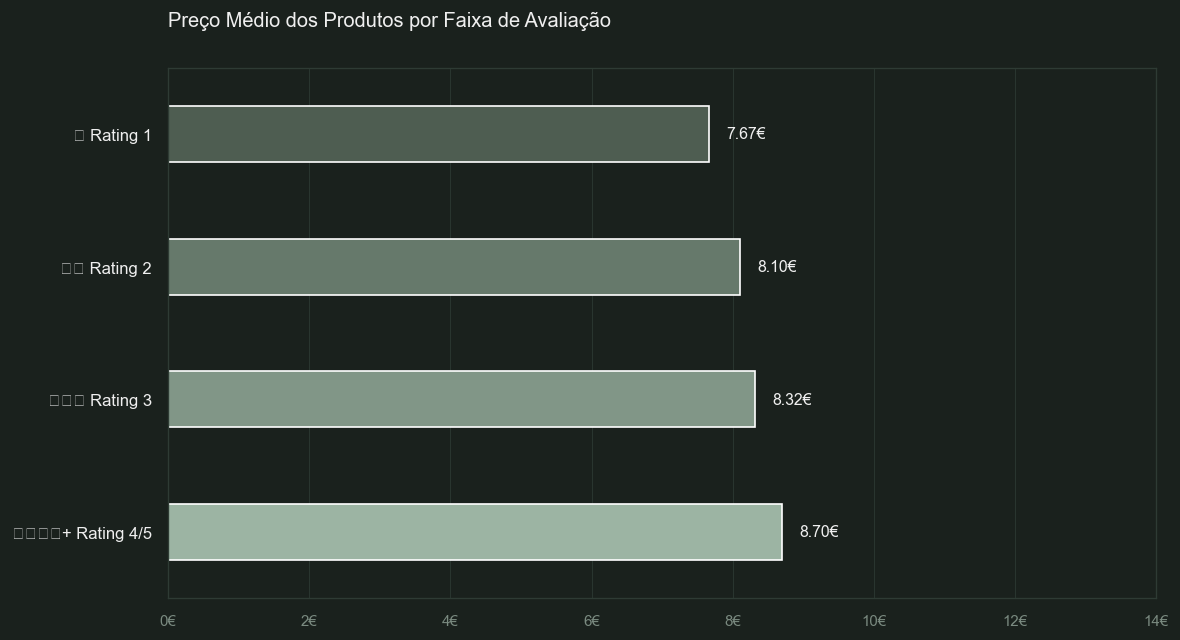

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Certificar o tipo numérico e calcular a média
df_rating['price_num'] = pd.to_numeric(df_rating['price'], errors='coerce')
df_preco_medio = df_rating.groupby('Faixa_Rating', observed=False)['price_num'].mean().reset_index()
df_preco_medio.columns = ['Faixa de Avaliação (Rating)', 'Preço Médio']

# 2. Configuração Visual Unificada (Idêntica ao Gráfico 1)
plt.figure(figsize=(10, 5.5), dpi=120) # Tamanho casado com o gráfico de cima
cor_fundo_slide = '#1A211D' 
plt.rcParams['figure.facecolor'] = cor_fundo_slide

ax = plt.subplot(111)
ax.set_facecolor(cor_fundo_slide)

paleta_branding = ['#4B5F4F', '#637C69', '#7D9A85', '#98B8A2']

# Invertemos para horizontal (x=Preço Médio, y=Faixa) para manter a simetria exata de leitura de blocos
ax = sns.barplot(
    data=df_preco_medio,
    x='Preço Médio',
    y='Faixa de Avaliação (Rating)',
    hue='Faixa de Avaliação (Rating)',
    palette=paleta_branding,
    legend=False,
    width=0.42,
    ax=ax
)

# --- SISTEMA DE GRADES PADRONIZADO (Espelhando as 7 divisões do gráfico 1) ---
ax.set_axisbelow(True)
plt.grid(axis='x', linestyle='-', linewidth=0.6, color='#2E3B34', alpha=0.8)

for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#2E3B34')
    ax.spines[spine].set_linewidth(0.8)

# Escala travada de 0€ a 14€ com passos de 2 (Gera exatamente os mesmos 7 blocos visuais)
plt.xlim(0, 14)
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14], [f'{x}€' for x in [0, 2, 4, 6, 8, 10, 12, 14]], fontsize=9, color='#7A8A80')
# --------------------------------------------------------

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.24, # Ajuste de padding proporcional para escala de valor menor
            p.get_y() + p.get_height()/2., 
            f'{width:.2f}€', 
            ha="left", 
            va="center",
            fontsize=9.5,
            color='#EFEFEF',
            weight='normal'
        )

plt.title('Preço Médio dos Produtos por Faixa de Avaliação', fontsize=12, pad=25, color='#EFEFEF', weight='normal', loc='left')
plt.xlabel('')
plt.ylabel('')
plt.yticks(fontsize=10, color='#EFEFEF')

plt.tight_layout()
plt.show()

/opt/homebrew/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84530/2104596055.py:107: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


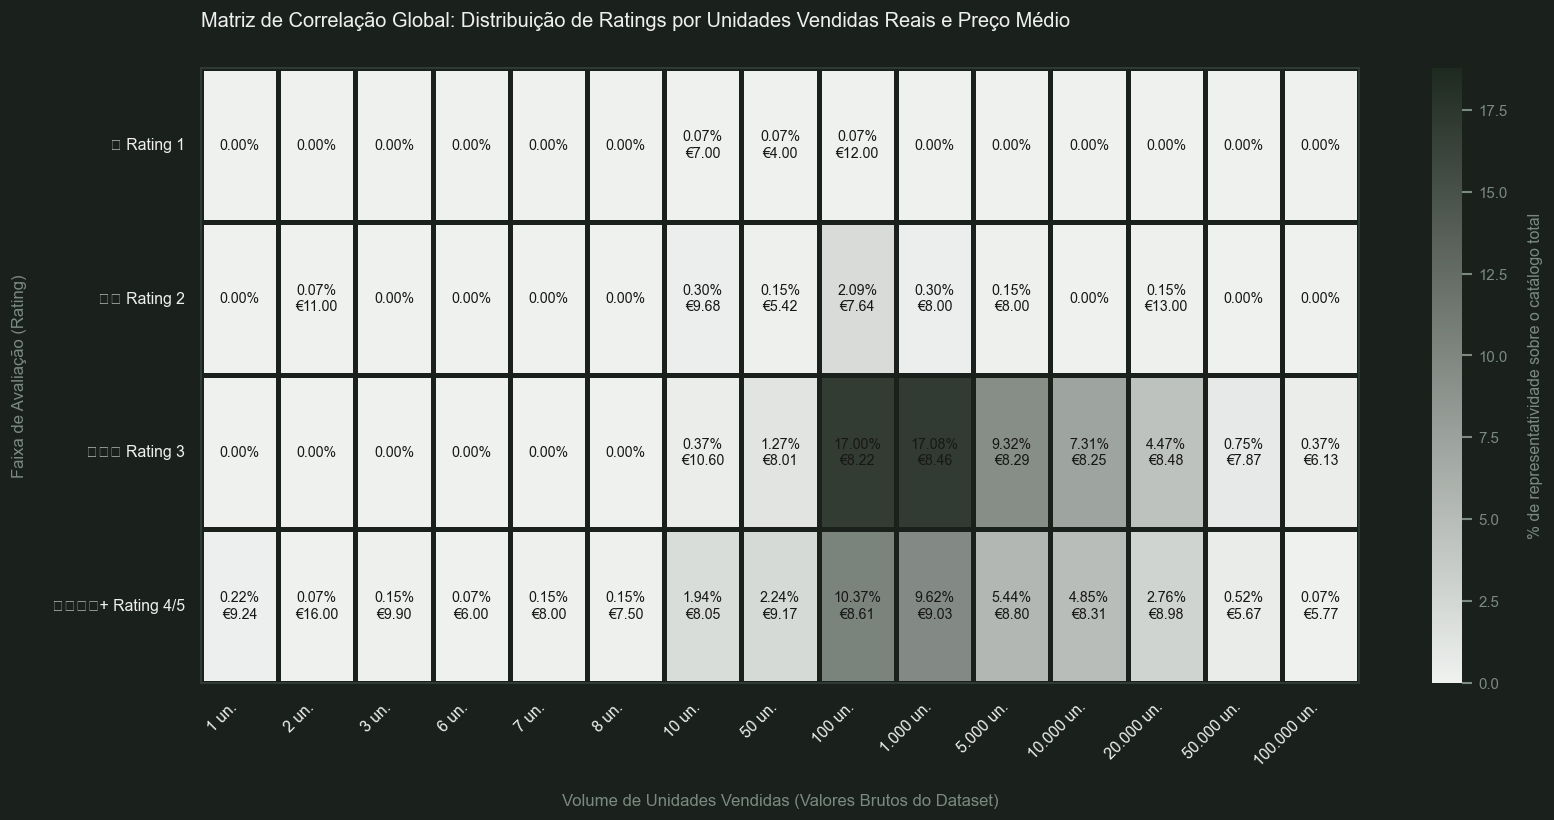

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tratamento e Isolamento Usando as Colunas Brutas do Dataset
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['price_num'] = pd.to_numeric(limpos_df['price'], errors='coerce')
limpos_df['units_sold_num'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# Garantir que pegamos apenas registros com dados válidos
df_matriz_bruta = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['units_sold_num'].notna()) & (limpos_df['price_num'].notna())
].copy()

# Faixas de Rating Estritas [fechado, aberto) para não duplicar produtos
bins_rating = [1.0, 2.0, 3.0, 4.0, 5.01]
labels_rating = ['★ Rating 1', '★★ Rating 2', '★★★ Rating 3', '★★★★+ Rating 4/5']
df_matriz_bruta['Faixa_Rating'] = pd.cut(df_matriz_bruta['rating_num'], bins=bins_rating, labels=labels_rating, right=False)

# Converter e ordenar os valores únicos de unidades vendidas de forma estritamente numérica
valores_vendas_ordenados = sorted(df_matriz_bruta['units_sold_num'].unique())

# Criar rótulos formatados para o eixo X (ex: "10 un.", "1.000 un.")
labels_vendas_brutas = [f"{int(val):,} un.".replace(',', '.') for val in valores_vendas_ordenados]

# Transformar a coluna em categórica ordenada usando os próprios números brutos
df_matriz_bruta['units_sold_Categorica'] = pd.Categorical(
    df_matriz_bruta['units_sold_num'], 
    categories=valores_vendas_ordenados, 
    ordered=True
)

# --- MATEMÁTICA DA MATRIZ (NORMALIZAÇÃO GLOBAL TOTAL = 100%) ---
matriz_percentual = pd.crosstab(
    df_matriz_bruta['Faixa_Rating'], 
    df_matriz_bruta['units_sold_Categorica'], 
    normalize='all'
) * 100

# Cruzamento do Preço Médio usando a coluna categórica idêntica
matriz_preco_medio = df_matriz_bruta.groupby(['Faixa_Rating', 'units_sold_Categorica'], observed=False)['price_num'].mean().unstack(fill_value=0)

# Garantir o alinhamento exato das dimensões das duas matrizes
matriz_preco_medio = matriz_preco_medio.reindex(columns=matriz_percentual.columns, fill_value=0)

# Montar o texto composto interno (Porcentagem Global + Preço Médio)
matriz_texto_composto = np.empty(matriz_percentual.shape, dtype=object)
for i in range(matriz_percentual.shape[0]):
    for j in range(matriz_percentual.shape[1]):
        pct = matriz_percentual.iloc[i, j]
        preco = matriz_preco_medio.iloc[i, j]
        
        if pct > 0:
            matriz_texto_composto[i, j] = f"{pct:.2f}%\n€{preco:.2f}"
        else:
            matriz_texto_composto[i, j] = "0.00%"

# 2. Configuração do Design Dark Mode do Slide
plt.figure(figsize=(14, 7), dpi=120)  # Aumentado levemente para acomodar todos os degraus brutos

cor_fundo_slide = '#1A211D'
plt.rcParams['figure.facecolor'] = cor_fundo_slide

ax = plt.subplot(111)
ax.set_facecolor(cor_fundo_slide)

# Paleta baseada no verde institucional escuro da marca
cmap_custom = sns.light_palette('#1E2920', as_cmap=True)

# Plotagem do Heatmap Correlacional Bruto
ax = sns.heatmap(
    matriz_percentual,
    annot=matriz_texto_composto,  
    fmt="",                       
    cmap=cmap_custom,
    vmin=0,
    vmax=matriz_percentual.to_numpy().max() * 1.1,
    linewidths=2.0,
    linecolor=cor_fundo_slide,
    cbar=True,
    xticklabels=labels_vendas_brutas, # Aplica as labels limpas e formatadas nos degraus reais
    annot_kws={"size": 8.5, "weight": "normal", "color": "#171717"} # Fonte levemente menor pelo volume de colunas
)

# Ajuste da barra lateral de intensidade
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#7A8A80')
cbar.set_label('% de representatividade sobre o catálogo total', color='#7A8A80', size=9.5, labelpad=12)

# Desenhar limites nítidos ao redor do bloco
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#2E3B34')
    ax.spines[spine].set_linewidth(1.2)

# Títulos e identificadores de eixos
plt.title('Matriz de Correlação Global: Distribuição de Ratings por Unidades Vendidas Reais e Preço Médio', fontsize=12, pad=25, color='#EFEFEF', weight='normal', loc='left')
plt.xlabel('Volume de Unidades Vendidas (Valores Brutos do Dataset)', fontsize=10, color='#7A8A80', labelpad=15)
plt.ylabel('Faixa de Avaliação (Rating)', fontsize=10, color='#7A8A80', labelpad=15)

# Rotação em 45 graus no eixo X porque agora temos muitos degraus de vendas únicos
plt.xticks(rotation=45, ha='right', fontsize=9.5, color='#EFEFEF')
plt.yticks(rotation=0, fontsize=9.5, color='#EFEFEF')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# 1. Garantir os tipos numéricos corretos nas colunas originais do seu dataset
df_rating['price_num'] = pd.to_numeric(df_rating['price'], errors='coerce')
df_rating['units_sold_pure'] = pd.to_numeric(df_rating['units_sold'], errors='coerce')
df_rating['rating_num'] = pd.to_numeric(df_rating['rating'], errors='coerce')

# 2. Calcular a receita de cada produto (Preço * Unidades Vendidas)
df_rating['receita_produto'] = df_rating['price_num'] * df_rating['units_sold_pure']

# 3. Calcular os totais globais e do segmento Top (Rating >= 4)
receita_global_total = df_rating['receita_produto'].sum()
df_top = df_rating[df_rating['rating_num'] >= 4]

X_produtos = df_top.shape[0]
Z_receita_top = df_top['receita_produto'].sum()
Y_percentual_receita = (Z_receita_top / receita_global_total) * 100

print("—" * 50)
print(f"X (Produtos): {X_produtos}")
print(f"Y (% da Receita): {Y_percentual_receita:.1f}%")
print(f"Z (Valor em Euros): {Z_receita_top:,.2f}€".replace(",", "."))
print("—" * 50)

——————————————————————————————————————————————————
X (Produtos): 518
Y (% da Receita): 36.5%
Z (Valor em Euros): 19.122.555.45€
——————————————————————————————————————————————————


/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84530/3967990207.py:88: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


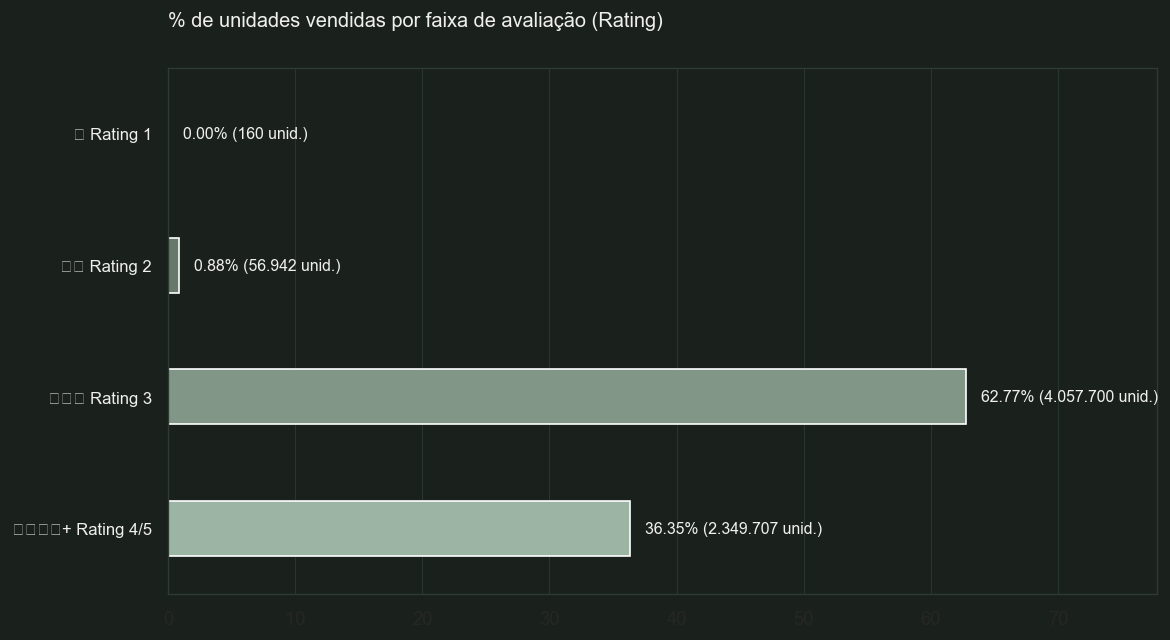

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento e Tratamento dos Dados
if 'limpos_df' not in globals():
    # Caso esteja utilizando o CSV fornecido:
    limpos_df = pd.read_csv('limpos_final_csv.csv')

# Garantir conversão numérica e tratar valores nulos
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['units_sold'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce').fillna(0)

# Filtrar intervalo válido de rating
df_rating = limpos_df[(limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5)].copy()

# Criação das faixas de rating
bins = [1.0, 2.0, 3.0, 4.0, 5.01]  
labels = ['★ Rating 1', '★★ Rating 2', '★★★ Rating 3', '★★★★+ Rating 4/5']
df_rating['Faixa_Rating'] = pd.cut(df_rating['rating_num'], bins=bins, labels=labels, right=False)

# 2. Agrupamento por Volume de Unidades Vendidas
df_vendas_rating = df_rating.groupby('Faixa_Rating', observed=False)['units_sold'].sum().reset_index(name='Total_Unidades_Vendidas')
total_unidades = df_vendas_rating['Total_Unidades_Vendidas'].sum()

# Calcular a proporção de vendas de cada faixa
df_vendas_rating['Percentual (%)'] = (df_vendas_rating['Total_Unidades_Vendidas'] / total_unidades) * 100

# 3. Configuração Visual Unificada (Estilo Verde Institucional)
plt.figure(figsize=(10, 5.5), dpi=120)
cor_fundo_slide = '#1A211D' 
plt.rcParams['figure.facecolor'] = cor_fundo_slide

ax = plt.subplot(111)
ax.set_facecolor(cor_fundo_slide)

# Paleta institucional verde
paleta_branding_verde = ['#4B5F4F', '#637C69', '#7D9A85', '#98B8A2']

ax = sns.barplot(
    data=df_vendas_rating,
    x='Percentual (%)',
    y='Faixa_Rating',
    hue='Faixa_Rating',
    palette=paleta_branding_verde,
    legend=False,
    width=0.42,
    ax=ax
)

# Sistema de grades e bordas
ax.set_axisbelow(True)
plt.grid(axis='x', linestyle='-', linewidth=0.6, color='#2E3B34', alpha=0.8)

for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#2E3B34')
    ax.spines[spine].set_linewidth(0.8)

# Limite estendido para acomodar os rótulos de texto de forma limpa
max_pct = df_vendas_rating['Percentual (%)'].max()
plt.xlim(0, max(max_pct + 15, 70)) 

# Rótulos de dados: Mostra a porcentagem e o valor absoluto formatado
for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        idx = int(p.get_y() + p.get_height()/2)
        vendas_reais = int(df_vendas_rating.loc[idx, 'Total_Unidades_Vendidas'])
        
        ax.text(
            width + 1.2, 
            p.get_y() + p.get_height()/2., 
            f'{width:.2f}% ({vendas_reais:,} unid.)'.replace(',', '.'),  
            ha="left", 
            va="center",
            fontsize=9.5,
            color='#EFEFEF',
            weight='normal'
        )

# Títulos e eixos
plt.title('% de unidades vendidas por faixa de avaliação (Rating)', fontsize=12, pad=25, color='#EFEFEF', weight='normal', loc='left')
plt.xlabel('')
plt.ylabel('')
plt.yticks(fontsize=10, color='#EFEFEF')

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd




import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]



# 1. Garantir que as colunas críticas estão no formato numérico correto
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['price_num'] = pd.to_numeric(limpos_df['price'], errors='coerce')
limpos_df['units_sold_pure'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# 2. Filtrar apenas o dataframe de produtos válidos (onde temos rating, preço e vendas)
df_validos = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['price_num'].notna()) & (limpos_df['units_sold_pure'].notna())
].copy()

# 3. Calcular a receita estimada de cada produto individual (Preço * Unidades Vendidas)
df_validos['receita_produto'] = df_validos['price_num'] * df_validos['units_sold_pure']

# 4. Calcular os Totais Globais do Catálogo Válido
total_produtos_catalogo = df_validos.shape[0]
receita_global_total = df_validos['receita_produto'].sum()

# 5. Isolar o segmento de Alta Qualidade (Rating >= 4)
df_alta_qualidade = df_validos[df_validos['rating_num'] >= 4]

# 6. Calcular os Valores para a Pergunta (X e Y)
produtos_alta_qualidade = df_alta_qualidade.shape[0]
receita_alta_qualidade = df_alta_qualidade['receita_produto'].sum()

Y_percentual_catalogo = (produtos_alta_qualidade / total_produtos_catalogo) * 100
X_percentual_receita = (receita_alta_qualidade / receita_global_total) * 100

# 7. Print dos resultados exatos para copiar e colar na pergunta
print("—" * 60)
print(f"VALORES ENCONTRADOS PARA A PERGUNTA 3:")
print(f"Y (% do Catálogo): {Y_percentual_catalogo:.2f}%")
print(f"X (% da Receita Total): {X_percentual_receita:.2f}%")
print("—" * 60)
print(f"Total de produtos desse segmento: {produtos_alta_qualidade} itens")
print(f"Receita gerada por esse segmento: €{receita_alta_qualidade:,.2f}".replace(",", "."))
print("—" * 60)

————————————————————————————————————————————————————————————
VALORES ENCONTRADOS PARA A PERGUNTA 3:
Y (% do Catálogo): 38.63%
X (% da Receita Total): 36.52%
————————————————————————————————————————————————————————————
Total de produtos desse segmento: 518 itens
Receita gerada por esse segmento: €19.122.555.45
————————————————————————————————————————————————————————————


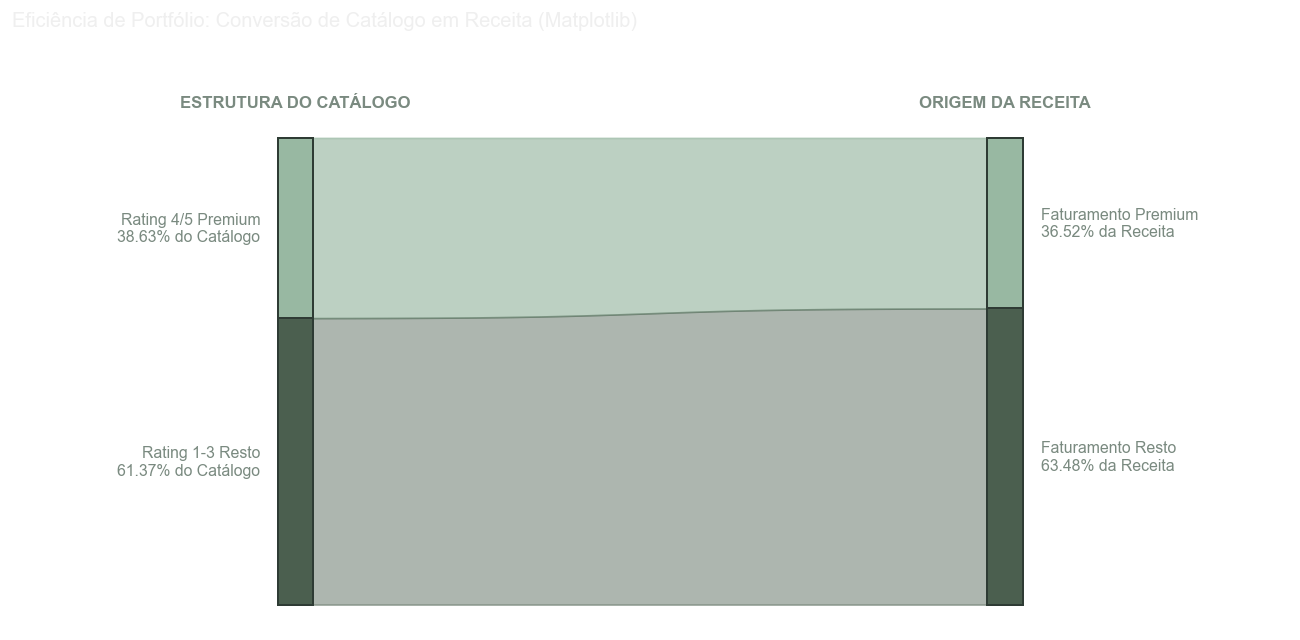

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Trazer as variáveis do seu bloco de validação anterior
pct_cat_premium = Y_percentual_catalogo
pct_cat_resto = 100 - Y_percentual_catalogo

pct_rec_premium = X_percentual_receita
pct_rec_resto = 100 - X_percentual_receita

# 2. Configuração Visual Dark Mode
plt.figure(figsize=(11, 5.5), dpi=120)
cor_fundo_slide = '#1A211D'
plt.rcParams['figure.facecolor'] = cor_fundo_slide

ax = plt.subplot(111)
ax.set_facecolor(cor_fundo_slide)

# Definir os tons verdes institucionais
verde_claro = '#98B8A2'
verde_escuro = '#4B5F4F'

# Coordenadas do fluxo (X inicial e final das colunas)
x_cat = 0.5
x_rec = 2.5
x_curva = np.linspace(x_cat, x_rec, 100)

# Função sutil de interpolação sigmoide para criar a curva do Sankey de forma elegante
def sigmoid_curve(x, y_start, y_end):
    # Normaliza x entre 0 e 1
    x_norm = (x - x.min()) / (x.max() - x.min())
    # Aplica a função logística para suavizar a transição
    s = 1 / (1 + np.exp(-10 * (x_norm - 0.5)))
    return y_start + (y_end - y_start) * s

# --- DESENHO DOS FLUXOS DE CONVERSÃO ---

# Fluxo 1: Premium (Parte Superior)
y1_cat_top = 100
y1_cat_bot = 100 - pct_cat_premium
y1_rec_top = 100
y1_rec_bot = 100 - pct_rec_premium

y_top_curve = sigmoid_curve(x_curva, y1_cat_top, y1_rec_top)
y_bot_curve = sigmoid_curve(x_curva, y1_cat_bot, y1_rec_bot)
ax.fill_between(x_curva, y_top_curve, y_bot_curve, color=verde_claro, alpha=0.65, label='Premium')

# Fluxo 2: Resto do Catálogo (Parte Inferior)
y2_cat_top = y1_cat_bot
y2_cat_bot = 0
y2_rec_top = y1_rec_bot
y2_rec_bot = 0

y_top_curve2 = sigmoid_curve(x_curva, y2_cat_top, y2_rec_top)
y_bot_curve2 = sigmoid_curve(x_curva, y2_cat_bot, y2_rec_bot)
ax.fill_between(x_curva, y_top_curve2, y_bot_curve2, color=verde_escuro, alpha=0.45, label='Resto')

# --- BARRAS DE ORIGEM E DESTINO ---
# Bloco do Catálogo (Esquerda)
ax.bar(x_cat, pct_cat_premium, width=0.1, bottom=y1_cat_bot, color=verde_claro, edgecolor='#2E3B34', linewidth=1.2)
ax.bar(x_cat, pct_cat_resto, width=0.1, bottom=y2_cat_bot, color=verde_escuro, edgecolor='#2E3B34', linewidth=1.2)

# Bloco da Receita (Direita)
ax.bar(x_rec, pct_rec_premium, width=0.1, bottom=y1_rec_bot, color=verde_claro, edgecolor='#2E3B34', linewidth=1.2)
ax.bar(x_rec, pct_rec_resto, width=0.1, bottom=y2_rec_bot, color=verde_escuro, edgecolor='#2E3B34', linewidth=1.2)

# --- TEXTOS E RÓTULOS EXECUTIVOS ---
# Labels da Esquerda (Catálogo)
ax.text(x_cat - 0.1, (y1_cat_top + y1_cat_bot)/2, f'Rating 4/5 Premium\n{pct_cat_premium:.2f}% do Catálogo', 
        ha='right', va='center', color='#7A8A80', fontsize=9.5)
ax.text(x_cat - 0.1, (y2_cat_top + y2_cat_bot)/2, f'Rating 1-3 Resto\n{pct_cat_resto:.2f}% do Catálogo', 
        ha='right', va='center', color='#7A8A80', fontsize=9.5)

# Labels da Direita (Receita)
ax.text(x_rec + 0.1, (y1_rec_top + y1_rec_bot)/2, f'Faturamento Premium\n{pct_rec_premium:.2f}% da Receita', 
        ha='left', va='center', color='#7A8A80', fontsize=9.5)
ax.text(x_rec + 0.1, (y2_rec_top + y2_rec_bot)/2, f'Faturamento Resto\n{pct_rec_resto:.2f}% da Receita', 
        ha='left', va='center', color='#7A8A80', fontsize=9.5)

# Cabeçalhos das Colunas
ax.text(x_cat, 106, 'ESTRUTURA DO CATÁLOGO', ha='center', va='bottom', color='#7A8A80', fontsize=10, weight='bold')
ax.text(x_rec, 106, 'ORIGEM DA RECEITA', ha='center', va='bottom', color='#7A8A80', fontsize=10, weight='bold')

# Limpar eixos e bordas desnecessárias
ax.set_xlim(x_cat - 0.8, x_rec + 0.8)
ax.set_ylim(-5, 115)
ax.axis('off')

plt.title('Eficiência de Portfólio: Conversão de Catálogo em Receita (Matplotlib)', 
          fontsize=12, pad=25, color='#EFEFEF', weight='normal', loc='left')

plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>